In [22]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import defaultdict
from mlxtend.frequent_patterns import apriori as ml_apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [85]:
INPUT_FILE = "/kaggle/input/datasets/amirdevil/online-supermarket-1m/Online_SuperMarket.csv"   # replace with full dataset if needed
df = pd.read_csv(INPUT_FILE)

In [5]:
df.head()

,Transaction_ID,Customer_ID,Day_of_Week,Hour,Last_Purchase,Section_ID,Section,Product_ID,Product,Order
0,2425083,49125,2,18,NaN,13,pantry,17,baking ingredients,1
1,2425083,49125,2,18,NaN,16,dairy eggs,91,soy lactosefree,2
2,2425083,49125,2,18,NaN,16,dairy eggs,36,butter,3
3,2425083,49125,2,18,NaN,4,produce,83,fresh vegetables,4
4,2425083,49125,2,18,NaN,4,produce,83,fresh vegetables,5


In [86]:
df.shape

(2019501, 10)

# Q1

# چون روز ها بر اساس اندیس گذاری در دیتاست ذخیره شده ، روز های آخر هفته را با اندیس 0 و 6 قرار میدهیم 

In [87]:
weekend_days = [0, 6]
df["Is_Weekend"] = df["Day_of_Week"].isin(weekend_days)

In [12]:
def time_period(hour):
    if hour < 8:
        return "00-07"
    elif hour < 16:
        return "08-15"
    return "16-23"

# با متد بالا ، خرید ها را به بازه زمانی ساعتی صبح ظهر شب تقسیم میکنیم

In [88]:
df["Time_Period"] = df["Hour"].apply(time_period)
df.head()

,Transaction_ID,Customer_ID,Day_of_Week,Hour,Last_Purchase,Section_ID,Section,Product_ID,Product,Order,Is_Weekend,Time_Period
0,2425083,49125,2,18,NaN,13,pantry,17,baking ingredients,1,False,16-23
1,2425083,49125,2,18,NaN,16,dairy eggs,91,soy lactosefree,2,False,16-23
2,2425083,49125,2,18,NaN,16,dairy eggs,36,butter,3,False,16-23
3,2425083,49125,2,18,NaN,4,produce,83,fresh vegetables,4,False,16-23
4,2425083,49125,2,18,NaN,4,produce,83,fresh vegetables,5,False,16-23


# بر اساس تحلیل زیر مشخص است که حدود نصف کل خرید های انجام شده ، در روز های پایانی هفته انجام شده اند

In [15]:
weekend_sales = df[df["Is_Weekend"]].shape[0]
weekday_sales = df[~df["Is_Weekend"]].shape[0]

sales_diff_pct = ((weekend_sales - weekday_sales) / max(weekday_sales,1))*100

print(f"Weekend Sales: {weekend_sales}")
print(f"Weekday Sales: {weekday_sales}")
print(f"Difference (%): {sales_diff_pct:.2f}")

Weekend Sales: 672582
Weekday Sales: 1346919
Difference (%): -50.07


In [16]:
# 1a Total purchased products
total_products = df.groupby(["Is_Weekend", "Time_Period"]).size()

# 1b Products by section
section_products = (
    df.groupby(["Is_Weekend", "Time_Period", "Section"])
      .size()
      .reset_index(name="Purchased_Products")
)

In [18]:
# 1c Customers and average products purchased
customer_stats = (
    df.groupby(["Is_Weekend", "Time_Period"])
      .agg(Customers=("Customer_ID", "nunique"),
           Products=("Product_ID", "count"))
)
customer_stats["Avg_Products_Per_Customer"] = (
    customer_stats["Products"] / customer_stats["Customers"]
)

In [19]:
transactions = (
    df.groupby("Transaction_ID")["Product"]
      .apply(list)
      .tolist()
)

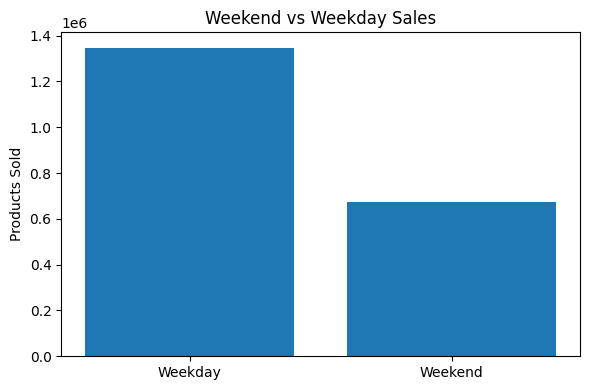

In [35]:
weekend_vs_weekday = (
    total_products
    .groupby(level=0)
    .sum()
)

plt.figure(figsize=(6,4))

plt.bar(
    ["Weekday", "Weekend"],
    weekend_vs_weekday.values
)

plt.title("Weekend vs Weekday Sales")
plt.ylabel("Products Sold")
plt.tight_layout()
plt.show()

# میانگین کل خرید ها به ازای روزهای هفته که مشاهده میشود نیمی از خرید مشتریان در دو روز پایانی هفته بوده است

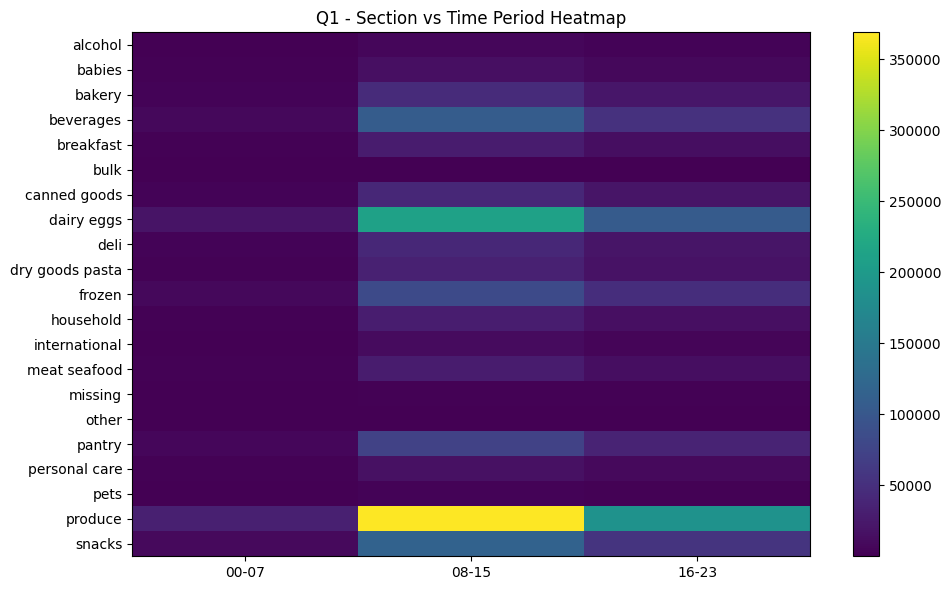

In [29]:
section_heatmap = (
    df.groupby(["Section","Time_Period"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(10,6))
plt.imshow(section_heatmap, aspect="auto")
plt.colorbar()
plt.title("Q1 - Section vs Time Period Heatmap")
plt.yticks(range(len(section_heatmap.index)), section_heatmap.index)
plt.xticks(range(len(section_heatmap.columns)), section_heatmap.columns)
plt.tight_layout()
plt.show()

# نمودار بالا ، ساعت خرید برای دسته بندی های مختلف را نمایش میدهد. مثلا خرید های در دسته تخم مرغ و لبنیات ، بیشتر در بازه ساعتی 8 صبح تا 3 ظهر ثبت شده است

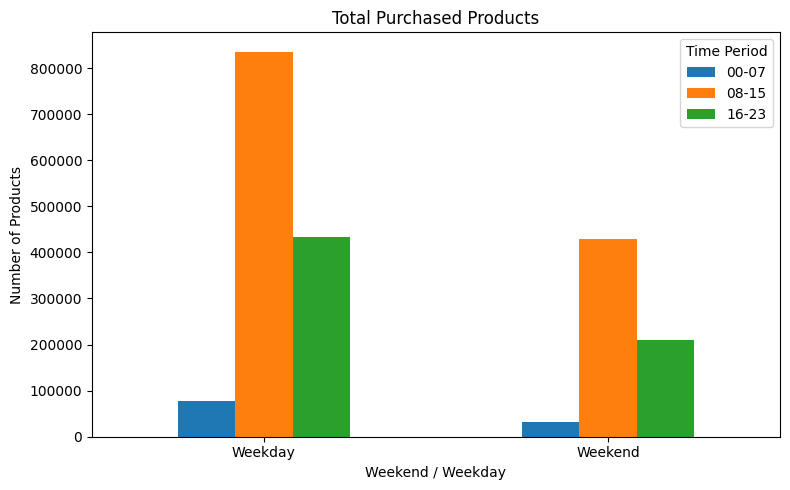

In [62]:
total_products.unstack().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Total Purchased Products")
plt.xlabel("Weekend / Weekday")
plt.ylabel("Number of Products")
plt.xticks(
    ticks=[0, 1],
    labels=["Weekday", "Weekend"],
    rotation=0
)
plt.legend(title="Time Period")
plt.tight_layout()
plt.show()

# میانگین تعداد کالای خریداری شده با توجه به ساعت شبانه روز و تفکیک روزهای پایانی هفته و غیرپایانی

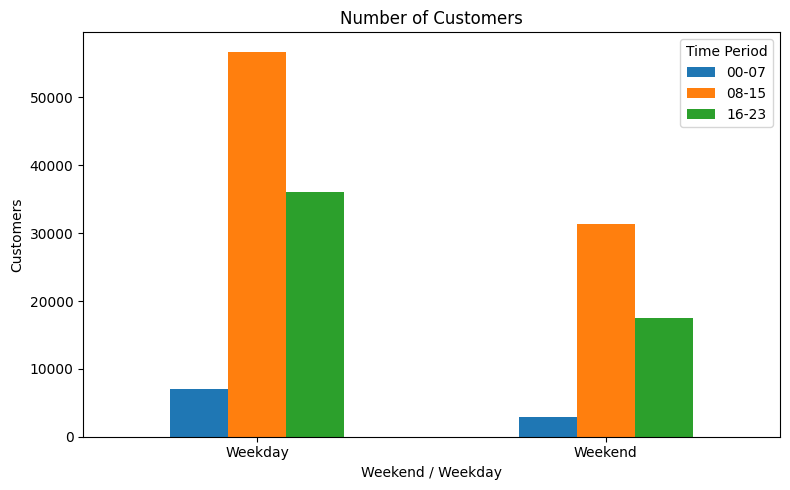

In [31]:
customer_stats["Customers"].unstack().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Customers")
plt.xlabel("Weekend / Weekday")
plt.ylabel("Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["Weekday", "Weekend"],
    rotation=0
)
plt.legend(title="Time Period")
plt.tight_layout()
plt.show()

# میانگین تعداد خریدهای انجام شده به ازای هر مشتری با توجه به ساعت شبانه روز و تفکیک روزهای پایانی هفته و غیرپایانی

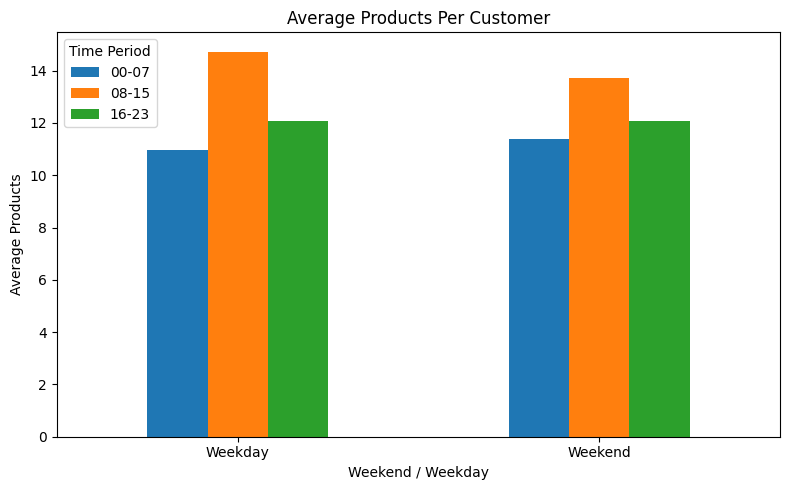

In [32]:
customer_stats["Avg_Products_Per_Customer"].unstack().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Products Per Customer")
plt.xlabel("Weekend / Weekday")
plt.ylabel("Average Products")
plt.xticks(
    ticks=[0, 1],
    labels=["Weekday", "Weekend"],
    rotation=0
)
plt.legend(title="Time Period")
plt.tight_layout()
plt.show()

# میانگین تعداد کالای موجود در سبد خرید هر مشتری در روز های معمولی بیشتر بوده و بطور میانگین بین 10 تا 14 کالا در سبد خرید خود داشتند

In [36]:
def custom_apriori(transactions, min_support=0.02):
    n = len(transactions)

    item_counts = defaultdict(int)
    for t in transactions:
        for item in set(t):
            item_counts[frozenset([item])] += 1

    frequent = {}
    Lk = {
        item: cnt / n
        for item, cnt in item_counts.items()
        if cnt / n >= min_support
    }

    k = 1
    while Lk:
        frequent.update(Lk)

        candidates = set()
        keys = list(Lk.keys())

        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                union = keys[i] | keys[j]
                if len(union) == k + 1:
                    candidates.add(union)

        counts = defaultdict(int)

        for t in transactions:
            tset = set(t)
            for c in candidates:
                if c.issubset(tset):
                    counts[c] += 1

        Lk = {
            c: cnt / n
            for c, cnt in counts.items()
            if cnt / n >= min_support
        }

        k += 1

    return frequent

# ما دیگر برروی قسمتی از داده اینکار را انجام نداده ایم ، برروی کل داده ها در محیط کگل الگوریتم اپریوری پیاده سازی شده اعمال شده است

In [66]:
frequent_itemsets = custom_apriori(transactions, min_support=0.02)

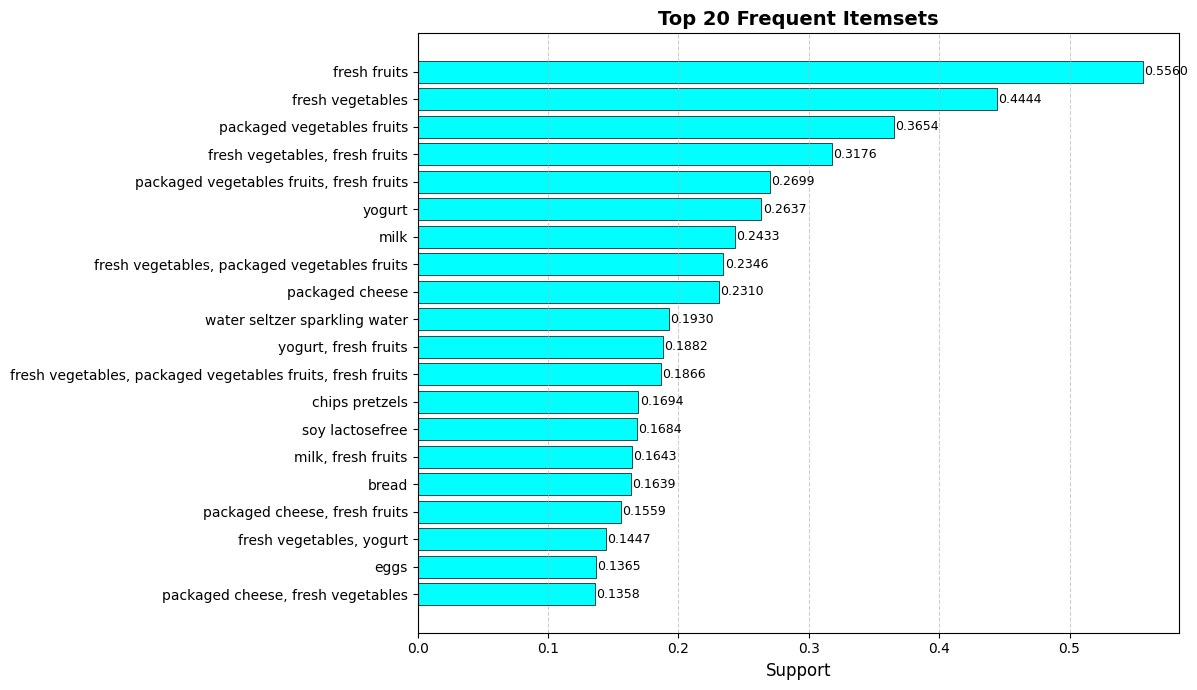

In [68]:
top_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:20]

labels = [", ".join(itemset) for itemset, _ in top_items]
supports = [round(support, 4) for _, support in top_items]

plt.figure(figsize=(12, 7))
bars = plt.barh(labels, supports, color='cyan', edgecolor='black', linewidth=0.5)

for bar, sup in zip(bars, supports):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{sup:.4f}', va='center', fontsize=9)

plt.xlabel("Support", fontsize=12)
plt.title("Top 20 Frequent Itemsets", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# میوه‌های تازه با ۵۵٫۶٪ و سبزیجات تازه با ۴۴٫۴٪، پرمصرف‌ترین و پرتکرارترین اقلامی هستند که در بیش از نیمی و نزدیک به نیمی از کل سبدهای خرید مشتریان وجود دارند.


# **Q2-a**


In [69]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# در کد زیر سبد خرید تولید میشود و قوانین انجمنی با میزان کانفیدنس بالای 70 درصد را نگه میداریم

In [42]:
basket = pd.DataFrame(te_array, columns=te.columns_)

freq = ml_apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

confidence = 0.70

rules = association_rules(
    freq,
    metric="confidence",
    min_threshold=0.70
).sort_values("confidence", ascending=False)

In [51]:
print(f"\nAssociation Rules (confidence >= {int(confidence*100)}%)")
rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(30)



Association Rules (confidence >= 70%)


,antecedents,consequents,support,confidence,lift
290,"(packaged vegetables fruits, fresh herbs, fres...",(fresh vegetables),0.039660,0.911934,2.052241
378,"(soy lactosefree, fresh vegetables, packaged v...",(fresh fruits),0.021475,0.905545,1.628693
293,"(fresh herbs, yogurt, fresh fruits)",(fresh vegetables),0.022570,0.902259,2.030468
373,"(fresh vegetables, packaged vegetables fruits,...",(fresh fruits),0.032845,0.900974,1.620471
287,"(packaged cheese, fresh herbs, fresh fruits)",(fresh vegetables),0.021765,0.899938,2.025245
367,"(fresh vegetables, packaged vegetables fruits,...",(fresh fruits),0.022825,0.898976,1.616878
376,"(packaged cheese, fresh vegetables, packaged v...",(fresh fruits),0.034565,0.894655,1.609106
208,"(packaged vegetables fruits, fresh herbs)",(fresh vegetables),0.046980,0.894261,2.012470
379,"(packaged cheese, packaged vegetables fruits, ...",(fresh fruits),0.021585,0.894159,1.608214
371,"(packaged cheese, fresh vegetables, yogurt, milk)",(fresh fruits),0.023210,0.894068,1.608050



# به عنوان یک توضیح برای قانون 293:اگر مشتری «سبزیجات تازه، ماست و میوه‌های تازه» را بخرد، در ۹۰.۲٪ موارد «سبزیجات تازه» را هم میخردخرید این اقلام با هم، رابطه‌ای قوی و غیرتصادفی دارند و پیشنهاد جانمایی کنار هم برای فروش بسیار مؤثر است


# Q2-b

In [70]:
ordered_counts = defaultdict(int)
antecedent_counts = defaultdict(int)

for tid, group in df.sort_values(
        ["Transaction_ID", "Order"]).groupby("Transaction_ID"):

    products = list(group["Product"])

    for i in range(len(products) - 1):
        antecedent_counts[products[i]] += 1

        for j in range(i + 1, len(products)):
            ordered_counts[(products[i], products[j])] += 1


# در کد زیر ، ممکن است با خروجی زیر مواجه شویم:('baby food formula', 'baby food formula', 2.096749296286207)این یعنی کسانی بودند که بیش از یک مورد از این کالا را خریداری کرده اند و مقدار آن هم زیاد بوده است.اگر شرط زیر را درنظر بگیریم ، این قوائد انجمنی حذف خواهند شد.a!= bاما به خودی خود این قوائد نیز میتوانند برای ما مفید باشند


In [71]:
ordered_rules = []

for (a, b), cnt in ordered_counts.items():
    conf = cnt / antecedent_counts[a]
    if conf >= 0.70 and a != b: # this can make repetation items goes on.
        ordered_rules.append((a, b, conf))

ordered_rules.sort(key=lambda x: x[2], reverse=True)

In [72]:
print("\nOrdered Rules")
for r in ordered_rules[: 30]:
    print(r)


Ordered Rules
('fresh herbs', 'fresh vegetables', 1.4867025005842487)
('poultry counter', 'fresh vegetables', 1.3130968622100956)
('seafood counter', 'fresh vegetables', 1.308071472581639)
('meat counter', 'fresh vegetables', 1.243)
('tofu meat alternatives', 'fresh vegetables', 1.2189115646258504)
('bulk grains rice dried goods', 'fresh vegetables', 1.1886010362694301)
('fresh fruits', 'fresh vegetables', 1.1593785124607574)
('eggs', 'fresh vegetables', 1.1204660194174758)
('packaged vegetables fruits', 'fresh vegetables', 1.1105821969506366)
('grains rice dried goods', 'fresh vegetables', 1.1013853904282116)
('canned jarred vegetables', 'fresh vegetables', 1.0967567891613212)
('packaged poultry', 'fresh vegetables', 1.092548435171386)
('canned meals beans', 'fresh vegetables', 1.0740788208907401)
('packaged meat', 'fresh vegetables', 1.0376616076447442)
('milk', 'fresh fruits', 1.0164743665992626)
('latino foods', 'fresh vegetables', 0.9985908877407234)
('soy lactosefree', 'fresh ve


# به عنوان یک نمونه از قانون استخراج شده در بالا('fresh herbs', 'fresh vegetables', 1.4867025005842487)احتمال خرید سبزیجات تازه درکنار میوه تازه بسیار بالا است.


# Q3

In [73]:
single_sales = (
    df["Product"]
    .value_counts()
)

best_sellers = set(single_sales.head(20).index)
low_sellers = set(single_sales.tail(20).index)


In [74]:
print("Rules:", len(rules))
print("Best sellers:", len(best_sellers))
print("Low sellers:", len(low_sellers))


rule_products = set()

for _, row in rules.iterrows():
    rule_products |= set(row["antecedents"])
    rule_products |= set(row["consequents"])

print("Low sellers appearing in rules:",
      len(low_sellers & rule_products))

print("Best sellers appearing in rules:",
      len(best_sellers & rule_products))

print("Low sellers in rules:" , low_sellers & rule_products)


Rules: 380
Best sellers: 20
Low sellers: 20
Low sellers appearing in rules: 0
Best sellers appearing in rules: 20
Low sellers in rules: set()



# با توجه به خروجی بالا ، مشاهده میکنیم اگر میزان آُستانه را صرفا 20 خرید پرتکرار و کمتکرار درنظر بگیریم ، به دلیل استفاده ازکانفیدنس 70 درصد ، هیچ قانونی وجود ندارد که در آن هم کالای پرخرید و هم کالای کم خرید اعمال شده باشد و خروجی خالی میشود.


# در اینجا ما بجای اینکه 20 درصد انتهایی کمترین خرید ها را نگه داریم ، بازه ای بین 45 درصد تا 65 درصد انتهایی خرید ها را نگه میداریم تا احتمال وجود قانونی که همپوشانی آن در پرفروش ترین و کم فروش ترین کالاها وجود داشته باشد را بیشتر کنیم

In [75]:
n = len(single_sales)

start_idx = int(n * 0.45)
end_idx = int(n * 0.65)

low_sellers = set(
    single_sales.iloc[start_idx:end_idx]
    .head(20)
    .index
)

In [76]:
print("Low sellers in rules:")
print(low_sellers & rule_products)

Low sellers in rules:
{'granola'}


# با توجه به خروجی بالا مشاهده میکنیم کالای گرانولا ، هم در قوائد انجمنی ما وجود دارد و هم یکی از کالاهای تقریبا کم فروش است

In [77]:
package_candidates = []

for _, row in rules.iterrows():
    items = set(row["antecedents"]) | set(row["consequents"])

    if any(i in low_sellers for i in items) and any(i in best_sellers for i in items):

        package_candidates.append({
            "items": items,
            "confidence": row["confidence"],
            "lift": row["lift"]
        })

print("\nSuggested Discount Packages")
for p in package_candidates[:10]:
    print(p)


Suggested Discount Packages
{'items': {'granola', 'fresh fruits'}, 'confidence': 0.725044404973357, 'lift': 1.304048426646565}


# به عنوان یک نمونه از قوائد انجمنی ترکیبی ، مشاهده میکنیم کالای کم فروش گرانولا در کنار میوه های تازه ، با احتمال بالایی خریداری شده است

# با جستجو در منابع آنلاین ، مشاهده میشود گرانولا همان جو پرک میباشد که بیشتر مردم آن را با ترکیب شیر و میوه های تازه استفاده میکنند

# Q4

In [78]:
section_map = (
    df[["Product", "Section"]]
    .drop_duplicates()
    .set_index("Product")["Section"]
    .to_dict()
)

merge_suggestions = defaultdict(int)

for _, row in rules.iterrows():
    items = list(set(row["antecedents"]) | set(row["consequents"]))

    sections = list({
        section_map.get(i, "Unknown")
        for i in items
    })

    if len(sections) >= 2:
        for pair in combinations(sorted(sections), 2):
            merge_suggestions[pair] += 1


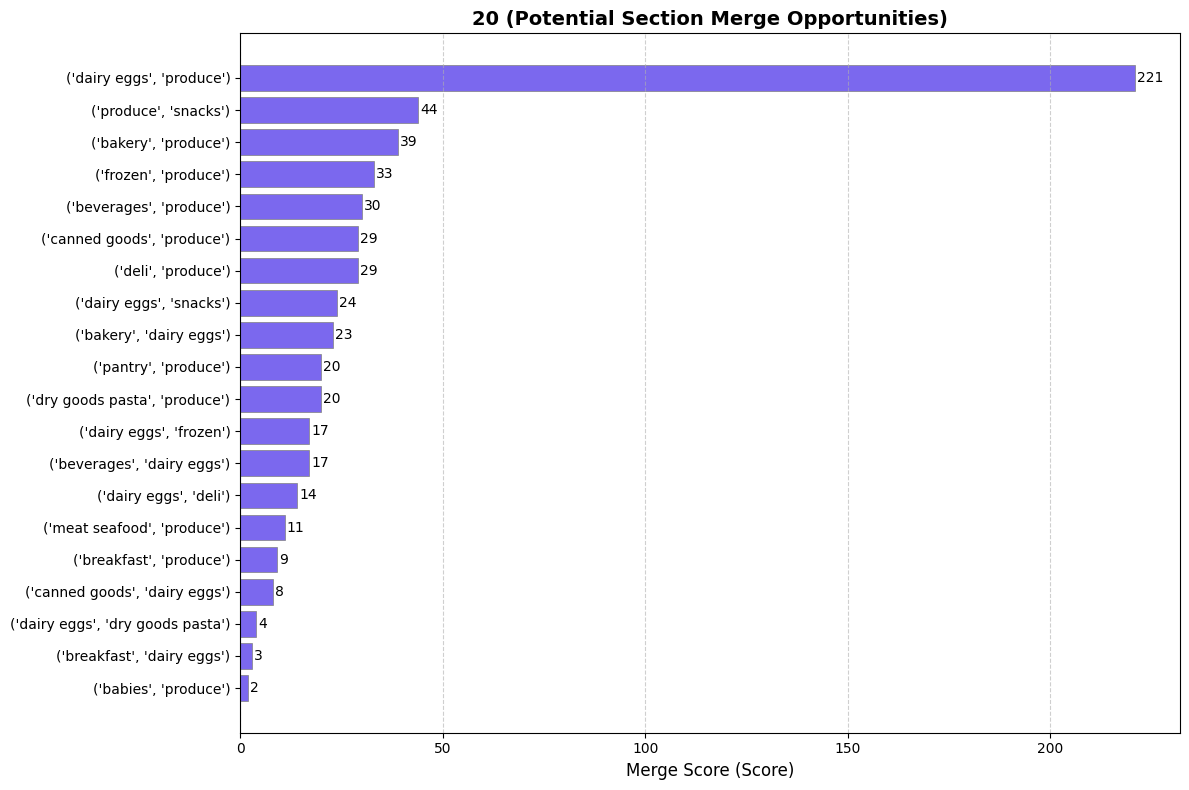

In [81]:
top_items = sorted(merge_suggestions.items(), key=lambda x: x[1], reverse=True)[:20]
df_q4 = pd.DataFrame(top_items, columns=["Section", "Score"])

labels = [str(section) for section in df_q4["Section"]]
scores = df_q4["Score"]

plt.figure(figsize=(12, 8))
bars = plt.barh(labels, scores, color='mediumslateblue', edgecolor='gray', linewidth=0.5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.5, 
             bar.get_y() + bar.get_height()/2, 
             f'{score}', 
             va='center', ha='left', fontsize=10)

plt.gca().invert_yaxis()

plt.xlabel("Merge Score (Score)", fontsize=12)
plt.title("20 (Potential Section Merge Opportunities)", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# با توجه به نمودار بالا ، یک ترکیب ایده آل میتواند ترکیب کالاهای میوه و سبزیجات با لبنیات روزانه باشد

# Q5

In [91]:
customer_features_v2 = (
    df.groupby("Customer_ID")
      .agg(
          Transactions=("Transaction_ID","nunique"),
          Products=("Product_ID","count"),
          Mean_Recency=("Last_Purchase","mean"),
          Max_Recency=("Last_Purchase","max"),
          Min_Recency=("Last_Purchase","min")
      )
)

customer_features_v2_clean = customer_features_v2[~np.isnan(customer_features_v2).any(axis=1)]

X2 = StandardScaler().fit_transform(customer_features_v2_clean)


# ما از روی دیتاست ، برای اینکه بدون مشکل در مدلهای یادگیری ماشین کار کنیمنیاز است تا داده های بدون مقدار را حذف کنیم یا با مقدار میانگین مناسب جایگزین کنیم


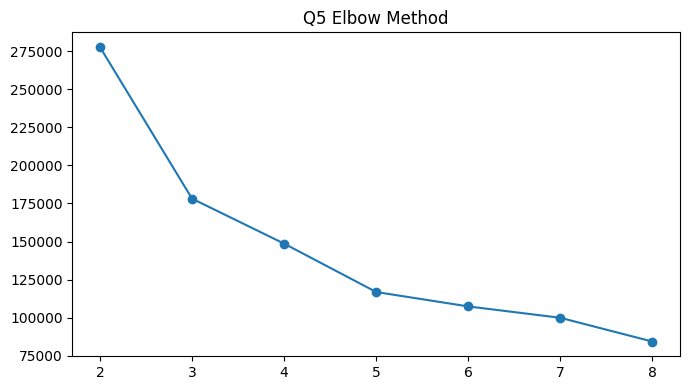

In [92]:
inertia_values = []

for k in range(2,9):
    model = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42
    )
    model.fit(X2)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,9), inertia_values, marker="o")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()



# چون شکل نهایی بصورت بازویی است ، میتوان نقطه ای که در آن شیب زیاد داریم را به عنوان خوشه مناسب درنظر بگیریمیعنی خوشه 3 یا 4 یا 5


In [94]:
# Silhouette
best_k = 2
best_score = -1

for k in range(2,8):

    model = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42
    )

    labels = model.fit_predict(X2)

    score = silhouette_score(X2, labels)

    if score > best_score:
        best_score = score
        best_k = k

print(f"Best K from silhouette: {best_k}")
print(f"Best silhouette score: {best_score:.4f}")

final_model = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=10000,
    random_state=42
)

Best K from silhouette: 3
Best silhouette score: 0.4705


In [98]:
cluster_summary = (
    customer_features_v2_clean
    .groupby("Cluster")
    .agg({
        "Transactions":"mean",
        "Products":"mean",
        "Mean_Recency":"mean",
        "Max_Recency":"mean",
        "Min_Recency":"mean"
    })
)

print(cluster_summary)

         Transactions   Products  Mean_Recency  Max_Recency  Min_Recency
Cluster                                                                 
0            1.383782  13.520402     25.077581    26.791048    23.047648
1            1.626348  14.516315      7.754218     9.175838     6.436137
2            4.725705  56.931619      7.790226    13.325273     3.431311


# مشتریان کم‌فعال (کلاستر 0): دارای تعداد تراکنش کم و فاصله زیاد از آخرین خرید.

# مشتریان عادی و فعال (کلاستر 1): دارای حجم خرید متوسط و فعالیت اخیر.

# مشتریان وفادار و ارزشمند (کلاستر 2): دارای بیشترین تعداد تراکنش، بیشترین حجم خرید و مشارکت بالا در فروش.

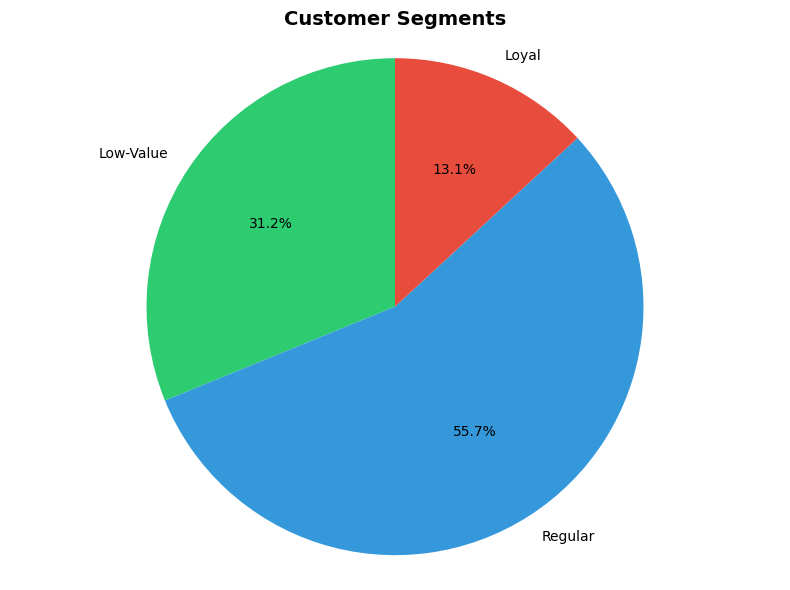

In [105]:
customer_features_v2_clean["Cluster"] = final_model.fit_predict(X2)
cluster_sizes = customer_features_v2_clean["Cluster"].value_counts().sort_index()

cluster_labels = {
    0: "Low-Value",
    1: "Regular",
    2: "Loyal"
}

labels = [cluster_labels[i] for i in cluster_sizes.index]

plt.figure(figsize=(8, 6))
plt.pie(
    cluster_sizes.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#3498db', '#e74c3c'])

plt.title("Customer Segments", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


تعداد مشتریان به ازای خوشه بندی انجام شده
30 درصد مشتریان وفادارند
60 درصد مشتریان عادی هستند
90 درصد 

In [101]:
customer_features_v2_clean.head()

,Transactions,Products,Mean_Recency,Max_Recency,Min_Recency,Cluster
Customer_ID,,,,,,
2,2,11,6.818182,10.0,3.0,1
3,3,19,12.421053,20.0,9.0,1
7,1,24,30.000000,30.0,30.0,0
10,1,30,14.000000,14.0,14.0,1
11,1,11,30.000000,30.0,30.0,0


# دسته بندی مشتریان بر مبنای خوشه بندی انجام شده و اضافه کردن یک ویژگی جدید به آنها

In [107]:
print('end')

end
